<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/03_superstore_sales_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/Sample - Superstore.csv', encoding='cp1252')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


**2. Data Cleaning**

In [7]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [9]:
# Derived time columns
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['order_month_name'] = df['Order Date'].dt.month_name()
df['order_weekday'] = df['Order Date'].dt.day_name()
df['shipping_duration'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['order_year', 'order_month_name', 'order_weekday', 'shipping_duration']].head()

,order_year,order_month_name,order_weekday,shipping_duration
0,2016,November,Tuesday,3
1,2016,November,Tuesday,3
2,2016,June,Sunday,4
3,2015,October,Sunday,7
4,2015,October,Sunday,7


In [10]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()
df.shape

(9994, 26)

**3. Univariate Analysis**

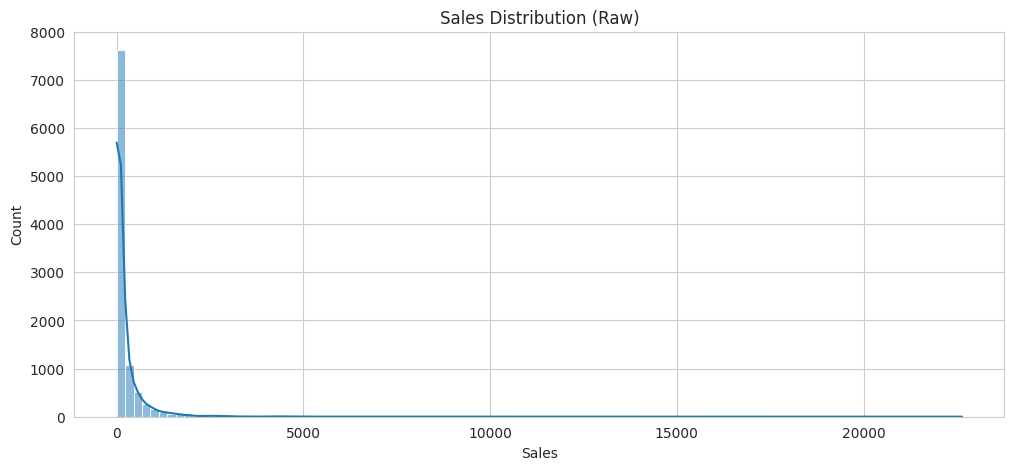

In [12]:
# Sales distribution
plt.figure(figsize=(12,5))
sns.histplot(df['Sales'], bins=100, kde=True)
plt.title('Sales Distribution (Raw)')
plt.show()

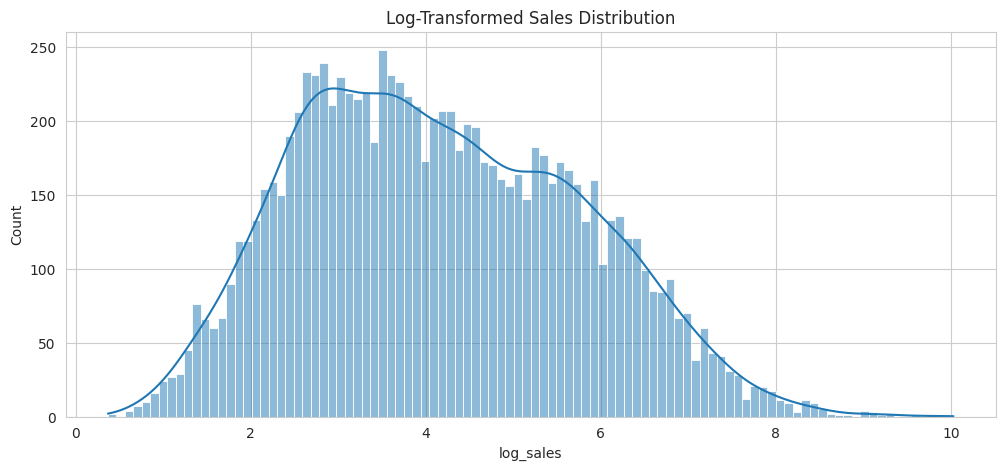

In [13]:
# Log-transformed sales (reusing skill from Project 2)
df['log_sales'] = np.log1p(df['Sales'])

plt.figure(figsize=(12,5))
sns.histplot(df['log_sales'], bins=100, kde=True)
plt.title('Log-Transformed Sales Distribution')
plt.show()

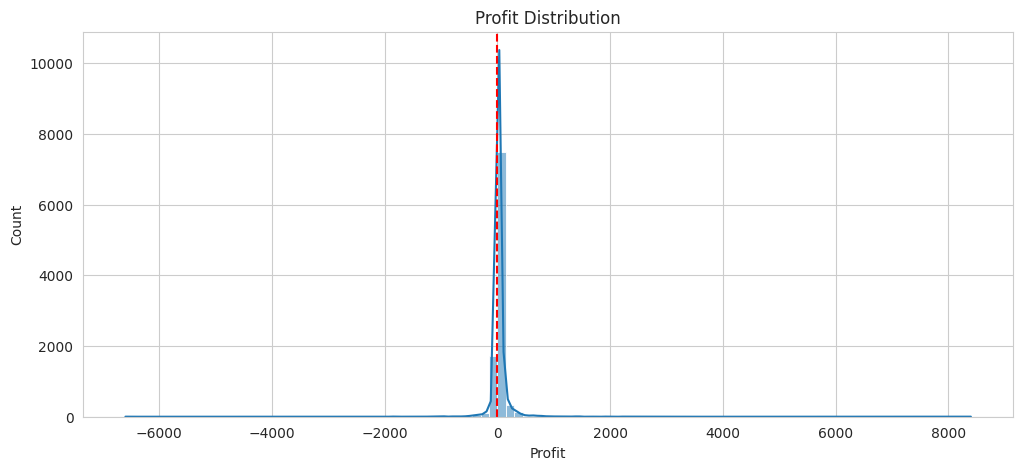

In [14]:
# Profit distribution - note profit can be negative, so no log transform here
plt.figure(figsize=(12,5))
sns.histplot(df['Profit'], bins=100, kde=True)
plt.title('Profit Distribution')
plt.axvline(0, color='red', linestyle='--')
plt.show()

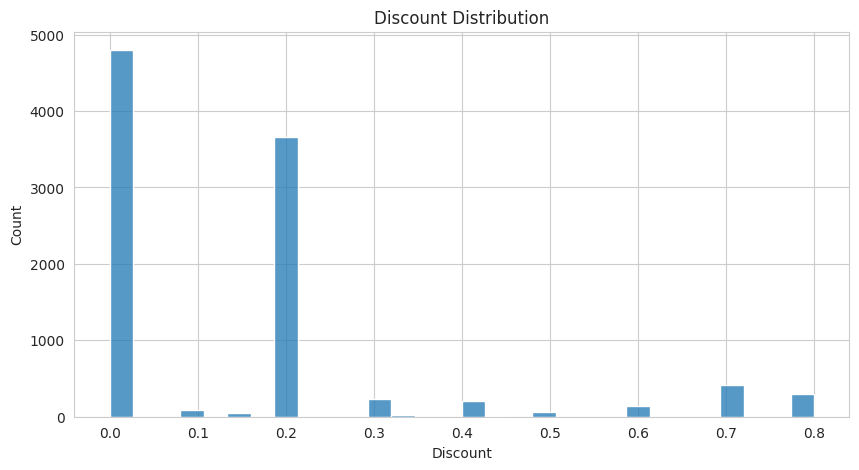

In [15]:
# Discount distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Discount'], bins=30)
plt.title('Discount Distribution')
plt.show()

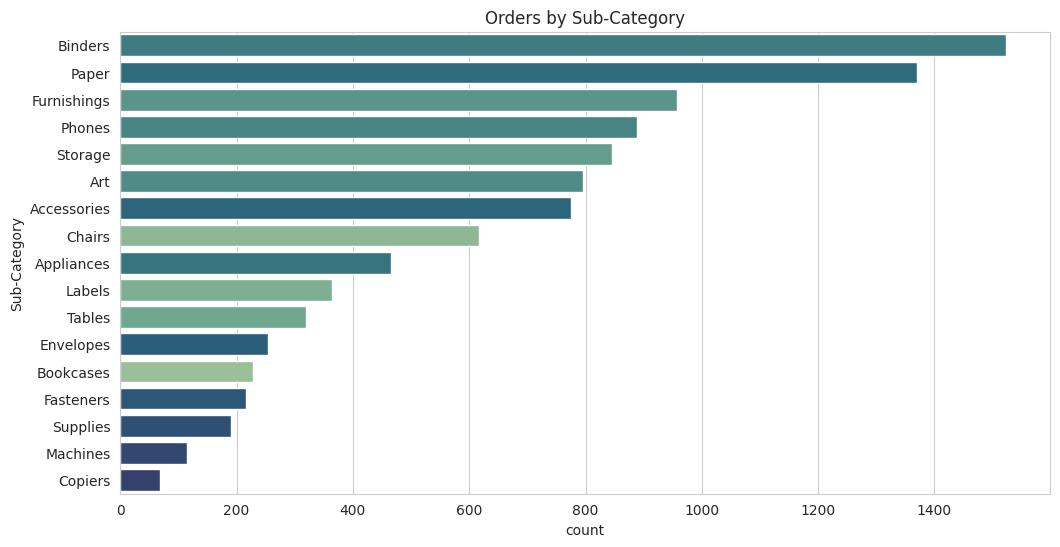

In [16]:
# Sub-category distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Sub-Category', hue='Sub-Category',
              order=df['Sub-Category'].value_counts().index, palette='crest', legend=False)
plt.title('Orders by Sub-Category')
plt.show()

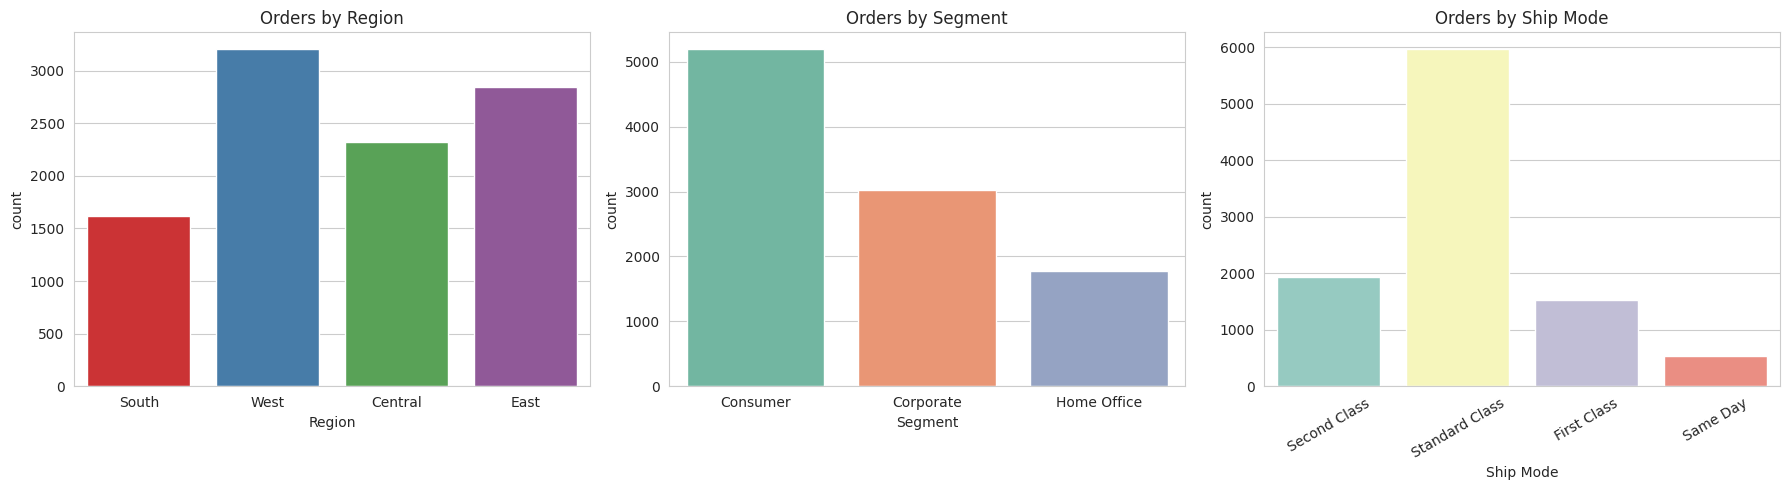

In [17]:
# Region, Segment, Ship Mode
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(data=df, x='Region', hue='Region', palette='Set1', legend=False, ax=axes[0])
axes[0].set_title('Orders by Region')

sns.countplot(data=df, x='Segment', hue='Segment', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Orders by Segment')

sns.countplot(data=df, x='Ship Mode', hue='Ship Mode', palette='Set3', legend=False, ax=axes[2])
axes[2].set_title('Orders by Ship Mode')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**4. Time Series Analysis**

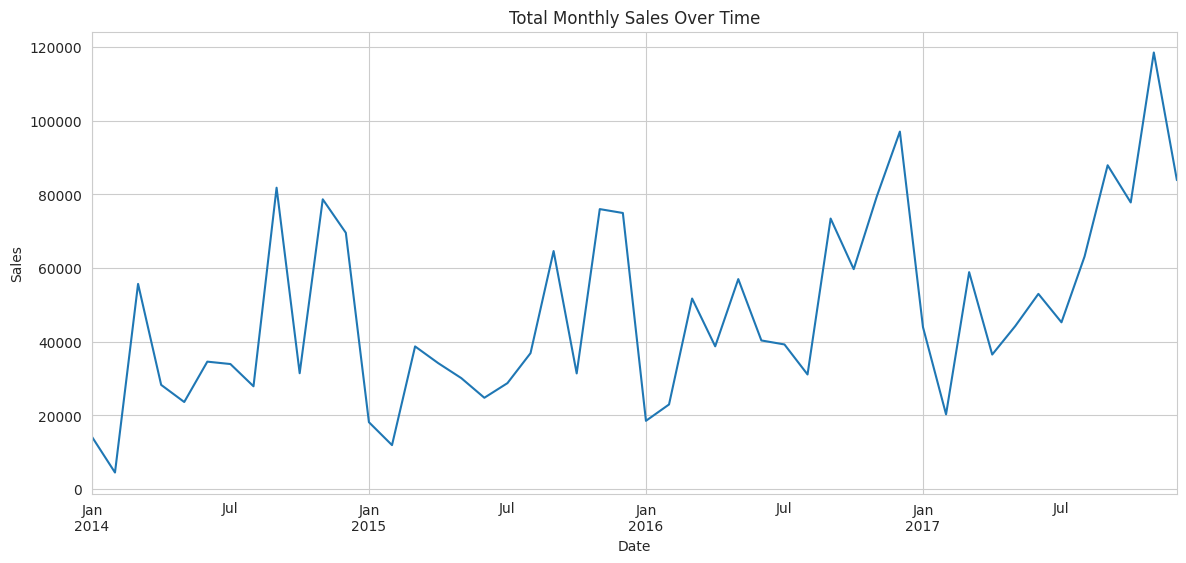

In [19]:
# Total sales over time - monthly resample
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title('Total Monthly Sales Over Time')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.show()

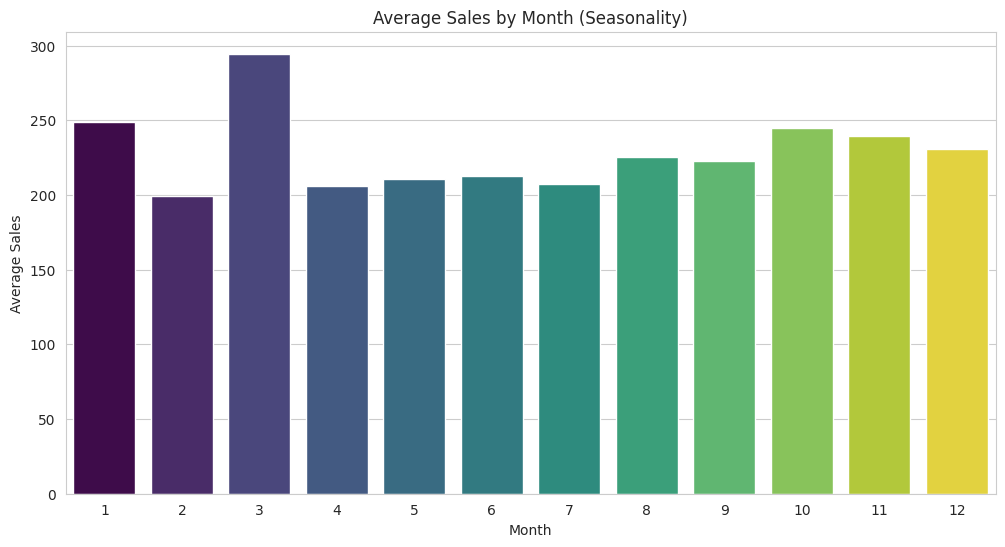

In [21]:
# Seasonality - average sales by month across years
monthly_avg = df.groupby('order_month')['Sales'].mean()

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, hue=monthly_avg.index, palette='viridis', legend=False)
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

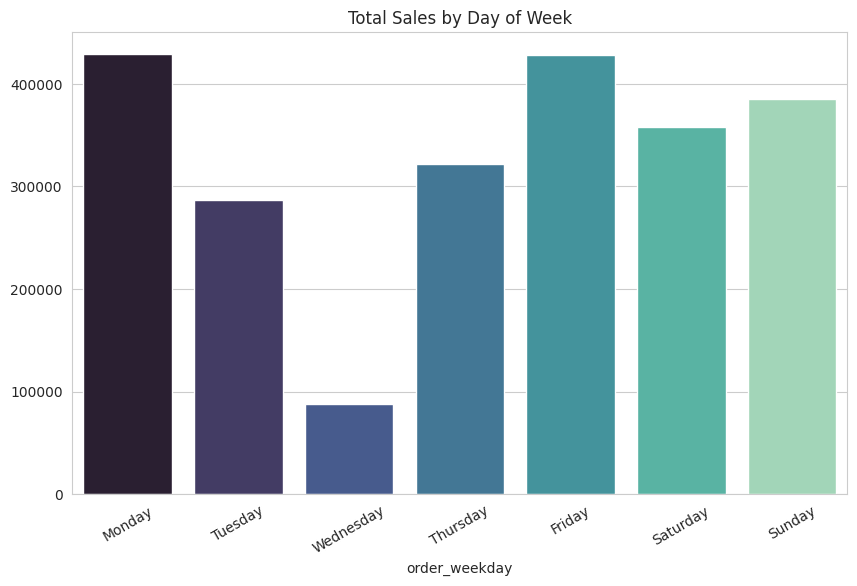

In [22]:
# Sales by day of week
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('order_weekday')['Sales'].sum().reindex(weekday_order)

plt.figure(figsize=(10,6))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, hue=weekday_sales.index, palette='mako', legend=False)
plt.title('Total Sales by Day of Week')
plt.xticks(rotation=30)
plt.show()

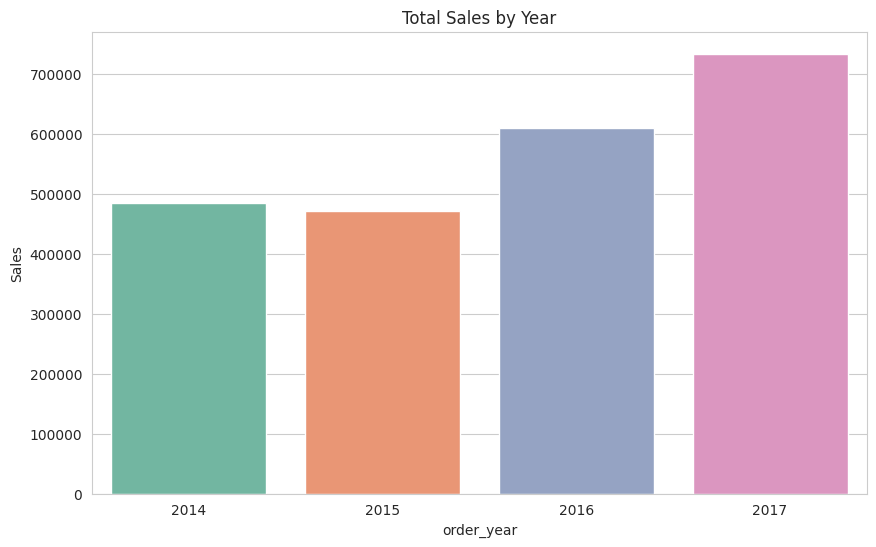

In [23]:
# Year-over-year comparison
yearly_sales = df.groupby('order_year')['Sales'].sum()

plt.figure(figsize=(10,6))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values, hue=yearly_sales.index, palette='Set2', legend=False)
plt.title('Total Sales by Year')
plt.ylabel('Sales')
plt.show()

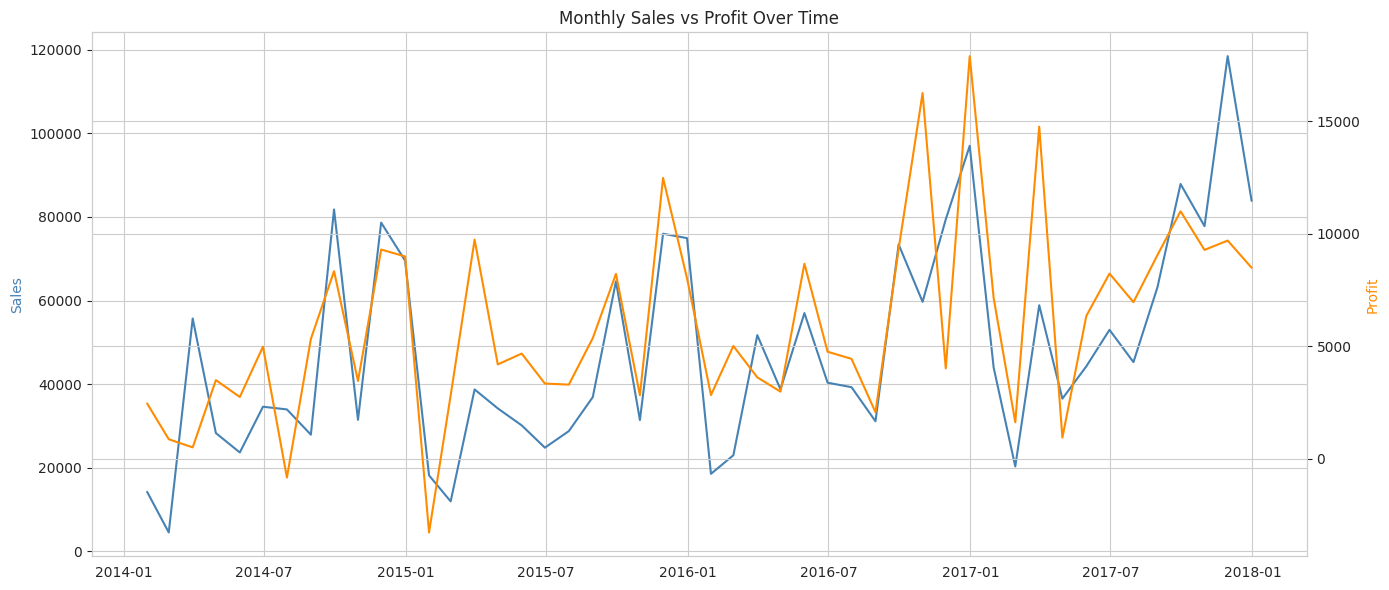

In [24]:
# Profit over time vs Sales over time
monthly_profit = df.set_index('Order Date').resample('ME')['Profit'].sum()

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(monthly_sales.index, monthly_sales.values, color='steelblue', label='Sales')
ax1.set_ylabel('Sales', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly_profit.index, monthly_profit.values, color='darkorange', label='Profit')
ax2.set_ylabel('Profit', color='darkorange')

plt.title('Monthly Sales vs Profit Over Time')
fig.tight_layout()
plt.show()

**5. Bivariate / Multivariate Analysis**

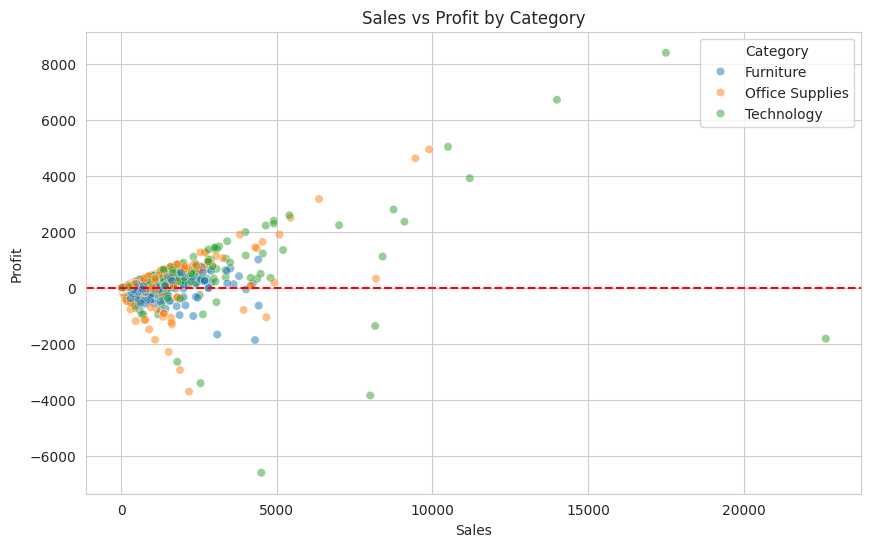

In [25]:
# Sales vs Profit, colored by Category
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Sales vs Profit by Category')
plt.show()

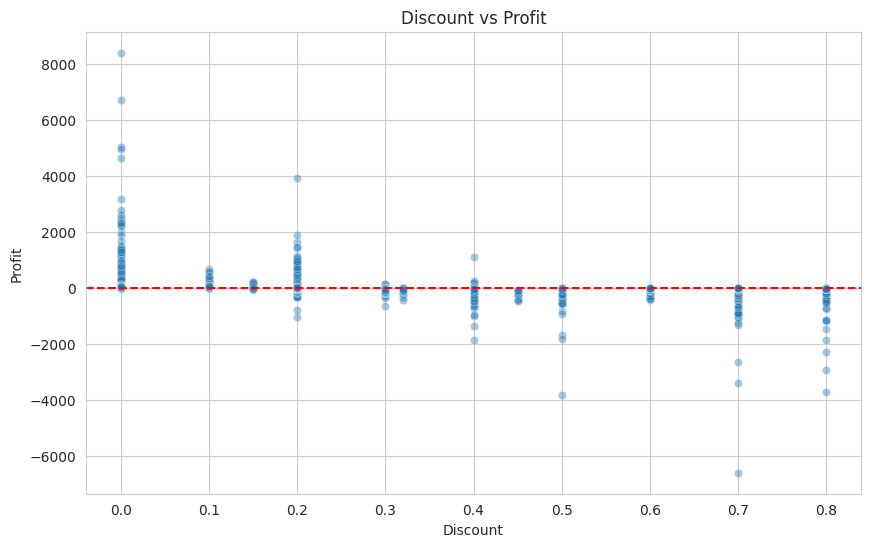

In [26]:
# Discount vs Profit - classic business question
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.show()

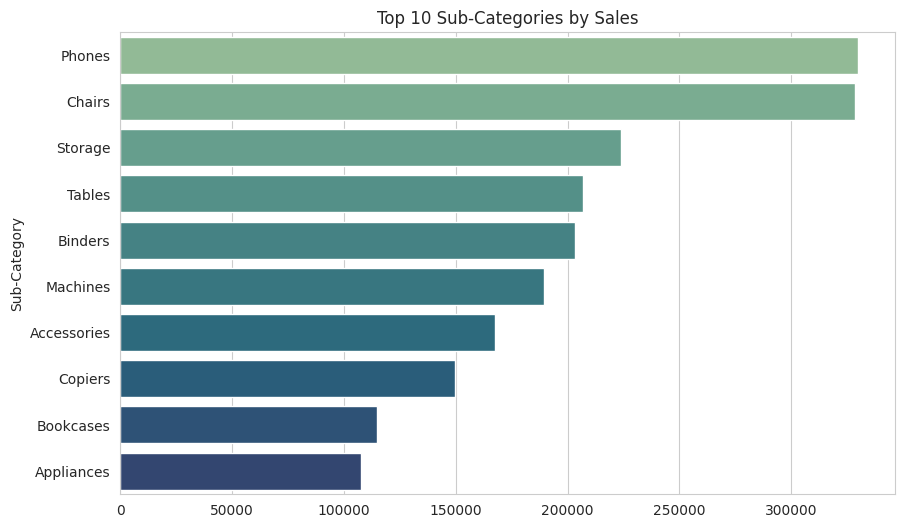

In [27]:
# Top 10 sub-categories by sales
top_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_sales.values, y=top_sales.index, hue=top_sales.index, palette='crest', legend=False)
plt.title('Top 10 Sub-Categories by Sales')
plt.show()

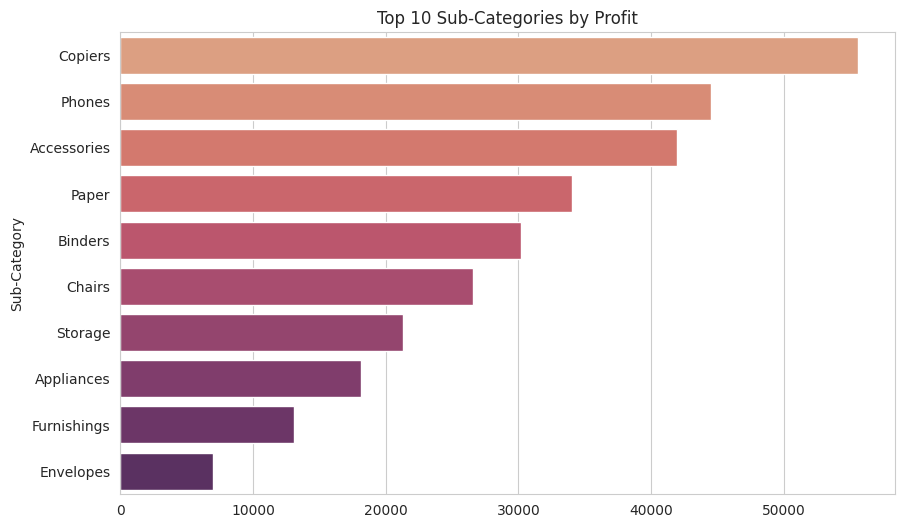

In [28]:
# Top 10 sub-categories by profit (compare to sales ranking above)
top_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_profit.values, y=top_profit.index, hue=top_profit.index, palette='flare', legend=False)
plt.title('Top 10 Sub-Categories by Profit')
plt.show()

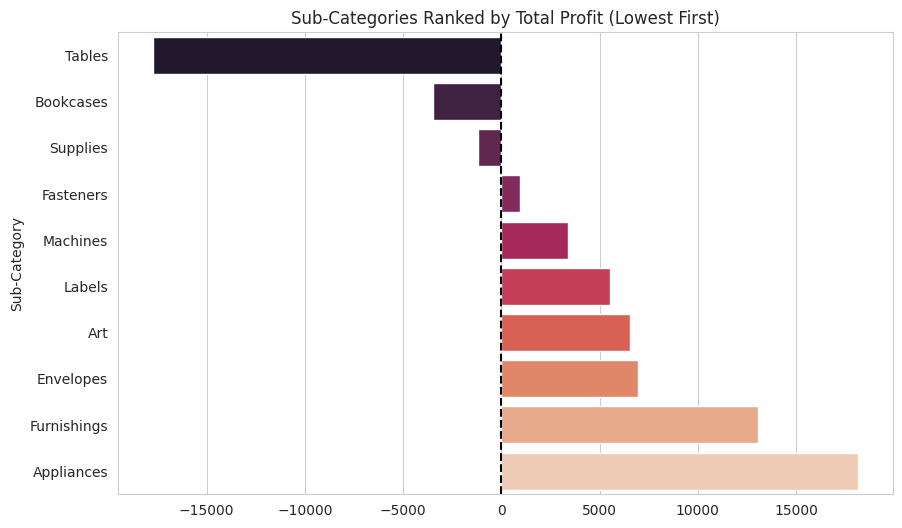

In [29]:
# Sub-categories with negative profit (the "losers")
loss_making = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)

sns.barplot(x=loss_making.values, y=loss_making.index, hue=loss_making.index, palette='rocket', legend=False)
plt.title('Sub-Categories Ranked by Total Profit (Lowest First)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

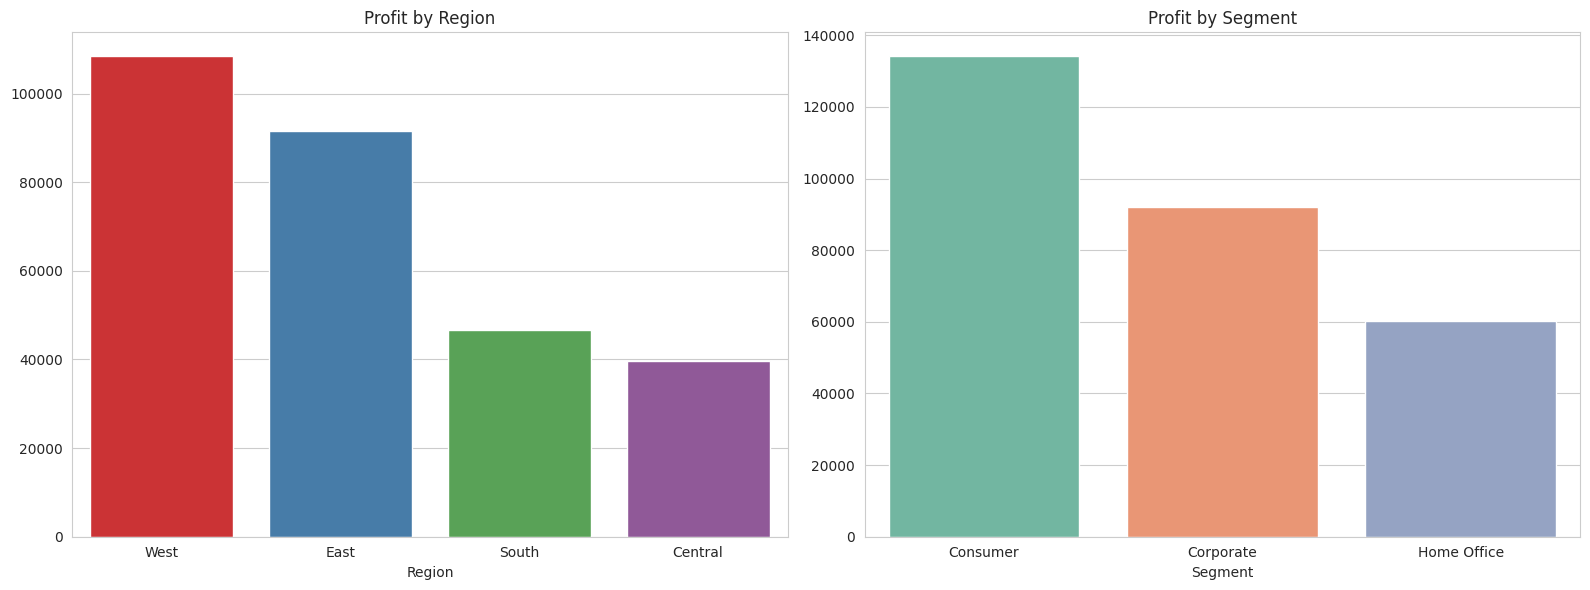

In [30]:
# Profit by Region and Segment
fig, axes = plt.subplots(1, 2, figsize=(16,6))

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=region_profit.index, y=region_profit.values, hue=region_profit.index, palette='Set1', legend=False, ax=axes[0])
axes[0].set_title('Profit by Region')

segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=segment_profit.index, y=segment_profit.values, hue=segment_profit.index, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Profit by Segment')

plt.tight_layout()
plt.show()

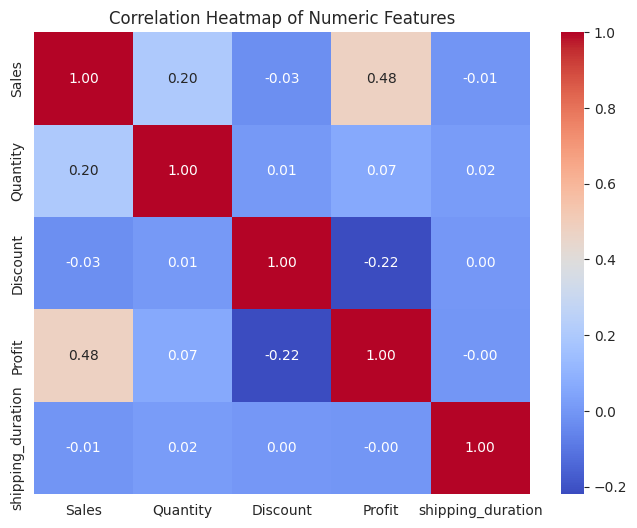

In [31]:
# Correlation heatmap
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'shipping_duration']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**6. Insights Summary**

## Key Insights

- Sales show a clear upward trend over the years, with strong seasonal spikes in November/December (holiday shopping).
- Profit does not always track sales — some periods with high sales show weak or negative profit.
- Higher discounts are strongly associated with lower (often negative) profit — discounting is eroding margins.
- [Sub-category] is the top performer by sales but not necessarily the most profitable — [Sub-category] shows the opposite pattern.
- [Region] generates the most profit while [Region] underperforms despite similar sales volume.
- Weekday sales patterns show [insert what you found — e.g., weekends vs weekdays].
- [Add 1-2 more insights specific to what you observed]